# 02 - Data Preparation, Preprocessing & EDA

Loads all raw datasets, standardises schema, merges, cleans, balances classes,
splits into train/val/test, and runs exploratory data analysis.

**Inputs:**
- `/kaggle/input/datasets/...` — raw datasets (phishing email, UCI SMS, job postings,
  NUS SMS corpus, Wikipedia MS/TA/ZH)
- the synthetic dataset generated by NB01 (`synthetic_dataset.csv`)

**Outputs:**
- `scamsense_full_dataset.csv`
- `train.csv`, `val.csv`, `test.csv`
- `train_norm.csv`, `val_norm.csv`, `test_norm.csv`
- `reports/figures/` — EDA plots


| Step | Description |
|---|---|
| 1 | Data Loading & Preparation |
| 2 | Data Preprocessing |
| 3 | EDA |


---
## 1: Data Loading & Preparation

### 1.1 Imports

In [ ]:
import os                                             # file paths and directory creation
import json                                           # reading the NUS SMS corpus JSON files
import warnings                                       # suppress noisy library warnings
import re                                             # regular expressions for text cleaning
import numpy as np                                    # numerical operations
import pandas as pd                                   # dataframes for loading / merging / saving data
import matplotlib.pyplot as plt                       # plotting (used later in EDA)
import matplotlib.ticker as mticker                   # custom axis tick formatting (EDA)
import seaborn as sns                                 # statistical plots (EDA)
from collections import Counter                       # counting occurrences (used later)
from sklearn.model_selection import train_test_split  # splitting data into train / val / test

warnings.filterwarnings("ignore")  # hide warning messages so output stays clean

# output directories
BASE_DIR    = "/kaggle/working"                    # Kaggle's writable working directory
DATA_DIR    = os.path.join(BASE_DIR, "data")       # where processed CSVs will be saved
REPORT_DIR  = os.path.join(BASE_DIR, "reports")    # where reports will be saved
FIGURES_DIR = os.path.join(REPORT_DIR, "figures")  # where EDA plots will be saved

for d in [DATA_DIR, REPORT_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)  # create each folder if it doesn't already exist

# dataset paths (raw inputs mounted from Kaggle datasets)
RAW_SYNTH = "/kaggle/input/datasets/bhoovika/scamscene-raw-dataset/synthetic_dataset.csv"                                       # synthetic scam messages from NB01
RAW_PHISH = "/kaggle/input/datasets/naserabdullahalam/phishing-email-dataset/phishing_email.csv"                                # phishing email dataset
RAW_UCI = "/kaggle/input/datasets/bhoovika/scamscene-raw-dataset/SMSSpamCollection"                                             # UCI SMS spam collection
RAW_JOBS = "/kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv"                       # real vs fake job postings
RAW_NUS_EN = "/kaggle/input/datasets/rtatman/the-national-university-of-singapore-sms-corpus/smsCorpus_en_2015.03.09_all.json"  # NUS SMS corpus (English / Singlish)
RAW_NUS_ZH = "/kaggle/input/datasets/rtatman/the-national-university-of-singapore-sms-corpus/smsCorpus_zh_2015.03.09.json"      # NUS SMS corpus (Mandarin)
RAW_WIKI_MS = "/kaggle/input/datasets/bhoovika/scamscene-raw-dataset/wiki_ms.csv"                                               # Wikipedia sentences (Malay) - used as ham
RAW_WIKI_TA = "/kaggle/input/datasets/bhoovika/scamscene-raw-dataset/wiki_ta.csv"                                               # Wikipedia sentences (Tamil) - used as ham
RAW_WIKI_ZH = "/kaggle/input/datasets/bhoovika/scamscene-raw-dataset/wiki_zh.csv"                                               # Wikipedia sentences (Mandarin) - used as ham

# split ratios
VAL_RATIO = 0.15   # 15% of data reserved for validation
TEST_RATIO = 0.15  # 15% of data reserved for testing (remaining 70% is train)
RANDOM_STATE = 42  # fixed seed so splits / sampling are reproducible

print("Imports done")
print("DATA_DIR:", DATA_DIR)


Imports done
DATA_DIR: /kaggle/working/data


### 1.2 Load scam sources (label = 1)

In [ ]:
scam_frames = []  # collect all scam (label=1) dataframes here before merging

# synthetic scam data
df_synth = pd.read_csv(RAW_SYNTH, encoding="utf-8-sig")                 # load NB01's synthetic scam messages
df_synth = df_synth[["text", "label", "language", "scam_type"]].copy()  # keep only the columns we need
df_synth["source"] = "synthetic_spf2025"                                # tag rows with where they came from

scam_frames.append(df_synth)
print(f"{'Synthetic scam':<25}: {len(df_synth):>7,} rows")

# phishing email dataset
df_phishing = pd.read_csv(                                        # load the phishing email CSV
    RAW_PHISH,
    usecols=["text_combined", "label"],                           # only load the two columns we need
    on_bad_lines="skip"                                           # skip any malformed rows instead of erroring
)
df_phishing.columns = ["text", "label"]                           # rename combined text column to our standard "text"
df_phishing["language"] = "en"                                    # this dataset is English-only
df_phishing["source"] = "phishing_email"                          # tag rows with where they came from

df_phishing_scam = df_phishing[df_phishing["label"] == 1].copy()  # split out the scam rows
df_phishing_ham = df_phishing[df_phishing["label"] == 0].copy()   # split out the ham rows (used later)

scam_frames.append(df_phishing_scam)
print(f"{'Phishing Email scam':<25}: {len(df_phishing_scam):>7,} rows")

# UCI SMS spam
df_uci = pd.read_csv(                                               # load the UCI SMS spam/ham dataset
    RAW_UCI,
    sep="\t",                                                       # file is tab-separated
    header=None,                                                    # file has no header row
    names=["label_str", "text"],                                    # assign our own column names
    on_bad_lines="skip"                                             # skip any malformed rows
)

df_uci_spam = df_uci[df_uci["label_str"] == "spam"].copy()          # keep only the spam (scam) rows
df_uci_spam["label"] = 1                                            # recode text label to numeric 1 = scam
df_uci_spam["language"] = "en"                                      # this dataset is English-only
df_uci_spam["source"] = "uci_sms_spam"                              # tag rows with where they came from
df_uci_spam = df_uci_spam[["text", "label", "language", "source"]]  # keep only the standard columns

scam_frames.append(df_uci_spam)
print(f"{'UCI SMS scam':<25}: {len(df_uci_spam):>7,} rows")

# fake job postings
df_jobs = pd.read_csv(                                     # load the real/fake job postings dataset
    RAW_JOBS,
    on_bad_lines="skip"                                    # skip any malformed rows
)

df_jobs["text"] = (                                        # combine title + description into a single text field
    df_jobs["title"].fillna("") + " " +
    df_jobs["description"].fillna("")
).str.strip()
df_jobs_scam = df_jobs[df_jobs["fraudulent"] == 1].copy()  # keep only the fraudulent postings
df_jobs_scam["label"] = 1                                  # recode to our standard label = 1 (scam)
df_jobs_scam["language"] = "en"                            # this dataset is English-only
df_jobs_scam["source"] = "job_postings_fake"               # tag rows with where they came from
df_jobs_scam = df_jobs_scam[                               # keep only the standard columns
    ["text", "label", "language", "source"]
]

scam_frames.append(df_jobs_scam)
print(f"{'Fake job postings scam':<25}: {len(df_jobs_scam):>7,} rows")

df_scam = pd.concat(scam_frames, ignore_index=True)  # stack all scam sources into one dataframe

print(f"\nTotal scam rows (before cleaning): {len(df_scam):,}")


Synthetic scam           :  24,383 rows
Phishing Email scam      :  42,891 rows
UCI SMS scam             :     747 rows
Fake job postings scam   :     866 rows

Total scam rows (before cleaning): 68,887


### 1.3 Load ham sources (label = 0)

In [ ]:
ham_frames = []  # collect all ham (label=0) dataframes here before merging

# phishing email ham
ham_frames.append(df_phishing_ham)  # reuse the ham split created in the previous cell
print(f"{'Phishing Email ham':<25}: {len(df_phishing_ham):>7,} rows")

# UCI SMS ham
df_uci_ham = df_uci[df_uci["label_str"] == "ham"].copy()  # keep only the ham (non-scam) rows
df_uci_ham["label"] = 0                                   # recode text label to numeric 0 = ham
df_uci_ham["language"] = "en"                             # this dataset is English-only
df_uci_ham["source"] = "uci_sms_ham"                      # tag rows with where they came from
df_uci_ham = df_uci_ham[                                  # keep only the standard columns
    ["text", "label", "language", "source"]
]

ham_frames.append(df_uci_ham)
print(f"{'UCI SMS ham':<25}: {len(df_uci_ham):>7,} rows")

# NUS SMS corpus
NUS_FILES = [                                    # list of (file path, language code) pairs to loop over
    (RAW_NUS_EN, "singlish"),
    (RAW_NUS_ZH, "zh")
]

for fpath, lang in NUS_FILES:                    # load and parse each NUS SMS corpus file
    with open(fpath, encoding="utf-8") as f:
        raw_json = json.load(f)                  # parse the JSON file
    messages = raw_json["smsCorpus"]["message"]  # list of message records
    texts = [                                    # pull out just the message text from each record
        m["text"]["$"]
        for m in messages
        if "$" in m.get("text", {})              # skip records that have no text field
    ]
    df_nus = pd.DataFrame({                      # build a standard dataframe for this language
        "text": texts,
        "label": 0,                              # all NUS SMS messages are treated as ham
        "language": lang,
        "source": "nus_sms"
    })
    ham_frames.append(df_nus)
    print(f"{f'NUS SMS ham ({lang})':<25}: {len(df_nus):>7,} rows")

# real job postings
df_jobs_ham = df_jobs[df_jobs["fraudulent"] == 0].copy()  # keep only the genuine (non-fraudulent) postings
df_jobs_ham["text"] = (                                   # combine title + description, same as the scam side
    df_jobs_ham["title"].fillna("") + " " +
    df_jobs_ham["description"].fillna("")
).str.strip()
df_jobs_ham["label"] = 0                                  # recode to our standard label = 0 (ham)
df_jobs_ham["language"] = "en"                            # this dataset is English-only
df_jobs_ham["source"] = "job_postings_real"               # tag rows with where they came from
df_jobs_ham = df_jobs_ham[                                # keep only the standard columns
    ["text", "label", "language", "source"]
]

ham_frames.append(df_jobs_ham)
print(f"{'Real job postings ham':<25}: {len(df_jobs_ham):>7,} rows")

# Wikipedia multilingual ham
WIKI_FILES = [                               # list of (file path, language code) pairs to loop over
    (RAW_WIKI_MS, "ms"),
    (RAW_WIKI_TA, "ta"),
    (RAW_WIKI_ZH, "zh")
]

for fpath, lang in WIKI_FILES:               # Wikipedia sentences act as clean, neutral ham text
    df_wiki = pd.read_csv(
        fpath,
        usecols=["text"],                    # only the text column is needed
        on_bad_lines="skip"                  # skip any malformed rows
    )
    df_wiki["label"] = 0                     # all Wikipedia sentences are treated as ham
    df_wiki["language"] = lang
    df_wiki["source"] = f"wikipedia_{lang}"  # tag rows with where they came from
    ham_frames.append(df_wiki)
    print(f"{f'Wikipedia ham ({lang})':<25}: {len(df_wiki):>7,} rows")

df_ham = pd.concat(ham_frames, ignore_index=True)  # stack all ham sources into one dataframe

print(f"\nTotal ham rows (before cleaning): {len(df_ham):,}")


Phishing Email ham       :  39,595 rows
UCI SMS ham              :   4,825 rows
NUS SMS ham (singlish)   :  55,835 rows
NUS SMS ham (zh)         :  31,460 rows
Real job postings ham    :  17,014 rows
Wikipedia ham (ms)       :   5,000 rows
Wikipedia ham (ta)       :   5,000 rows
Wikipedia ham (zh)       :   5,000 rows

Total ham rows (before cleaning): 163,729


### 1.4 Merge and schema standardisation

In [ ]:
from IPython.display import display  # nicer table rendering in the notebook

# merge all
df = pd.concat([df_scam, df_ham], ignore_index=True)  # combine scam + ham rows into one dataframe
print(f"Raw merged: {df.shape}")

# standardise types
df["text"]     = df["text"].astype(str)      # force text column to string type
df["label"]    = df["label"].astype(int)     # force label column to integer type
df["language"] = df["language"].astype(str)  # force language column to string type
df["source"]   = df["source"].astype(str)    # force source column to string type

def assign_scam_type(row):                                            # work out a consistent scam_type label for every row
    if pd.notna(row["scam_type"]):                                    # synthetic rows already have a scam_type - just remap it
        synthetic_map = {
            "phishing":                 "scam_phishing",
            "rental":                   "scam_rental",
            "investment":               "scam_investment",
            "charity":                  "scam_charity",
            "parcel_delivery":          "scam_parcel_delivery",
            "fake_friend":              "scam_fake_friend",
            "prize":                    "scam_prize",
            "bank_impersonation":       "scam_bank_impersonation",
            "loan":                     "scam_loan",
            "ecommerce":                "scam_ecommerce",
            "government_impersonation": "scam_government_impersonation",
            "job_scam":                 "scam_job",
        }
        return synthetic_map.get(row["scam_type"], row["scam_type"])  # fall back to original value if not in the map

    s = str(row["source"]).lower()                                    # otherwise, infer a scam_type from the source name

    if row["label"] == 0:                                             # ham rows get a ham_* label based on their source
        if "nus" in s:      return "ham_sms"
        if "wiki" in s:     return "ham_text"
        if "job" in s:      return "ham_job"
        if "phishing" in s: return "ham_email"
        if "uci" in s:      return "ham_sms"
        return "ham_other"                                            # fallback for any unmatched ham source

    if "phishing" in s: return "scam_phishing"                        # scam rows get a scam_* label based on their source
    if "job" in s:      return "scam_job"
    if "uci" in s:      return "scam_sms_spam"
    return "scam_other"                                               # fallback for any unmatched scam source

df["scam_type"] = df.apply(assign_scam_type, axis=1)  # apply the function above to every row

print("\nSchema:")
display(df.dtypes.to_frame("dtype"))  # show the final column types

print("\nSample row from each language:")
sample_df = (  # pick one random example row per language, for a quick visual check
    df.groupby("language", group_keys=False)
      .apply(lambda x: x.sample(1, random_state=42))
      .reset_index(drop=True)
)
display(sample_df[["text", "label", "language", "scam_type", "source"]])


Raw merged: (232616, 5)

Schema:


,dtype
text,object
label,int64
language,object
scam_type,object
source,object



Sample row from each language:


,text,label,language,scam_type,source
0,Creative Web Designer (Frontend/UX/Wordpress) ...,0,en,ham_job,job_postings_real
1,"Hai, nombor telah berubah. ini saya. transfer ...",1,ms,scam_fake_friend,synthetic_spf2025
2,U go home and take a good meal hor,0,singlish,ham_sms,nus_sms
3,சூலகம் (Ovary) கருமுட்டையை உற்பத்தி செய்யும் உ...,0,ta,ham_text,wikipedia_ta
4,"没有经验.远程助理每天取20000SGD. 现在回答,以避免罚款.",1,zh,scam_job,synthetic_spf2025


### 1.5 Basic checks

In [ ]:
print("NULL COUNTS")
print(df.isnull().sum())  # check for any missing values per column
print()

print("LABEL DISTRIBUTION")
print(df["label"].value_counts())  # how many scam (1) vs ham (0) rows we have
print()

print("LANGUAGE DISTRIBUTION")
print(df["language"].value_counts())  # how many rows per language
print()

print("ONE SAMPLE PER LANGUAGE")
for lang in df["language"].unique():   # print one example message per language as a sanity check
    sample = df[df["language"] == lang]["text"].iloc[0]
    print(f"[{lang}] {sample[:120]}")  # show only the first 120 characters
    print()


NULL COUNTS
text         0
label        0
language     0
scam_type    0
source       0
dtype: int64

LABEL DISTRIBUTION
label
0    163729
1     68887
Name: count, dtype: int64

LANGUAGE DISTRIBUTION
language
en          110938
singlish     60835
zh           41424
ms            9781
ta            9638
Name: count, dtype: int64

ONE SAMPLE PER LANGUAGE
[zh] 卖方需要在运送前存款250SGD.请在24小时内回复.

[en] Official notice from Ministry of Health. This is your final notice.

[ta] உங்கள் SGD 1000 NTUC வவுச்சர் கோரப்படுவதற்கு காத்திருக்கிறது. நள்ளிரவுக்கு முன் பதிலளிக்கவும்.

[ms] Tiada pengalaman diperlukan. pembantu separuh masa mendapat S$ 20 setiap hari. Klik pautan untuk menyelesaikan.

[singlish] Aiya need money fast? S$ 100 loan, no check one.



---
## 2: Data Preprocessing

### 2.1 Missing values, short texts, duplicates

In [ ]:
# drop nulls
before = len(df)                 # remember row count so we can report how many were dropped
df = df.dropna(subset=["text"])  # remove rows with a missing text value
print(f"{'Dropped nulls':<40}: {before - len(df):>7,} rows")

# strip whitespace
df["text"] = df["text"].str.strip()  # remove leading/trailing whitespace from every message

# drop literal 'nan' strings
before = len(df)
df = df[df["text"].str.lower() != "nan"]  # remove rows where text literally became the string "nan"
print(f"{'Dropped literal nan strings':<40}: {before - len(df):>7,} rows")

# drop very short texts (< 5 chars)
before = len(df)
df = df[df["text"].str.len() >= 5]  # messages under 5 characters carry little signal
print(f"{'Dropped short texts (<5 chars)':<40}: {before - len(df):>7,} rows")

# cap very long texts to 2,000 characters
truncated = (df["text"].str.len() > 2000).sum()  # count how many rows will be truncated
df["text"] = df["text"].str[:2000]               # keep only the first 2,000 characters of each message
print(f"{'Texts truncated (>2,000 chars)':<40}: {truncated:>7,} rows")

# deduplicate on (text, language)
before = len(df)
df = df.drop_duplicates(subset=["text", "language"]).reset_index(drop=True)  # remove exact repeats within the same language
print(f"{'Dropped (text, language) duplicates':<40}: {before - len(df):>7,} rows")

# deduplicate on text alone (cross-language)
before = len(df)
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)  # remove the same text if it also appears under another language tag
print(f"{'Dropped cross-language duplicates':<40}: {before - len(df):>7,} rows")

# near-duplicate removal (normalised: lowercase + strip punctuation)
# catches capitalisation variants, punctuation-only differences (e.g. "Anytime!" vs "Anytime...")
df["_norm"] = (                                                   # build a temporary normalised column just for comparing near-duplicates
    df["text"]
    .str.lower()                                                  # ignore case differences
    .str.replace(r"[^\w\s]", "", regex=True)                      # strip punctuation
    .str.strip()
)
before = len(df)
df = df.drop_duplicates(subset=["_norm"]).reset_index(drop=True)  # drop rows that are duplicates once normalised
df.drop(columns=["_norm"], inplace=True)                          # remove the temporary helper column
print(f"{'Dropped near-duplicates (normalised)':<40}: {before - len(df):>7,} rows")

# drop punctuation-only rows
before = len(df)
df = df[  # keep only rows where the alphanumeric content is at least 5 characters
    df["text"]
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.strip()
    .str.len() >= 5
]
print(f"{'Dropped punctuation-only rows':<40}: {before - len(df):>7,} rows")

print(f"\n{'Dataset shape':<40}: {str(df.shape):>7}")  # final shape after all cleaning steps


Dropped nulls                           :       0 rows
Dropped literal nan strings             :       0 rows
Dropped short texts (<5 chars)          :   6,944 rows
Texts truncated (>2,000 chars)          :  23,017 rows
Dropped (text, language) duplicates     :   9,777 rows
Dropped cross-language duplicates       :   3,476 rows
Dropped near-duplicates (normalised)    :   1,490 rows
Dropped punctuation-only rows           :   1,482 rows

Dataset shape                           : (209447, 5)


### 2.2 Label check

In [ ]:
# Label and scam_type integrity check
print("Label values:", df["label"].unique())                                  # show the distinct label values present
assert set(df["label"].unique()).issubset({0, 1}), "unexpected label values"  # fail loudly if any label isn't 0 or 1
print("Label check passed")
print(df["label"].value_counts())

# ham rows must not carry scam scam_types
scam_types_for_scams = {                                                          # the set of scam_type values that should only appear on scam rows
    "scam_phishing", "scam_rental", "scam_investment", "scam_charity",
    "scam_parcel_delivery", "scam_fake_friend", "scam_prize",
    "scam_bank_impersonation", "scam_loan", "scam_ecommerce",
    "scam_government_impersonation", "scam_job", "scam_sms_spam", "scam_other",
}
bad_rows = df[(df["label"] == 0) & (df["scam_type"].isin(scam_types_for_scams))]  # find any ham rows mislabelled with a scam_type
print(f"Ham rows with scam scam_type: {len(bad_rows)}")
if len(bad_rows) > 0:
    print(bad_rows["source"].value_counts())                                      # show which sources caused the mismatch
    # fix: reset scam_type to ham_other for misclassified rows
    df.loc[bad_rows.index, "scam_type"] = "ham_other"                             # correct the mislabelled rows
    print("Fixed: scam_type reset to ham_other for affected rows")
else:
    print("No scam_type conflicts found")


Label values: [1 0]
Label check passed
label
0    140982
1     68465
Name: count, dtype: int64
Ham rows with scam scam_type: 0
No scam_type conflicts found


### 2.3 Language verification

In [ ]:
print("Languages present:", df["language"].unique().tolist())          # list every language code found in the data
print()
print("Per-language label breakdown:")
print(df.groupby(["language", "label"]).size().unstack(fill_value=0))  # scam vs ham counts, per language


Languages present: ['zh', 'en', 'ta', 'ms', 'singlish']

Per-language label breakdown:
label         0      1
language              
en        58563  49093
ms         4974   4773
singlish  43115   5000
ta         4997   4637
zh        29333   4962


### 2.4 Scam type mapping

In [ ]:
print("Scam types (scam rows only):")
print(df[df["label"] == 1]["scam_type"].value_counts())  # how many rows fall under each scam_type


Scam types (scam rows only):
scam_type
scam_phishing                    44845
scam_job                          2989
scam_loan                         2162
scam_parcel_delivery              2147
scam_fake_friend                  2108
scam_rental                       2062
scam_ecommerce                    2051
scam_investment                   2023
scam_prize                        2016
scam_charity                      1906
scam_bank_impersonation           1828
scam_government_impersonation     1697
scam_sms_spam                      631
Name: count, dtype: int64


### 2.5 Class balancing (global undersampling)


In [ ]:
# Run a global undersample where total ham is capped to total scam count regardless of language.

scam_total = (df["label"] == 1).sum()  # total number of scam rows across all languages
ham_total  = (df["label"] == 0).sum()  # total number of ham rows across all languages

print(f"Before global undersample: scam={scam_total:,}  ham={ham_total:,}")

df_global_ham  = df[df["label"] == 0].sample(n=scam_total, random_state=RANDOM_STATE)  # randomly keep only as many ham rows as there are scam rows
df_global_scam = df[df["label"] == 1]                                                  # keep all scam rows
df_global = pd.concat([df_global_scam, df_global_ham], ignore_index=True)              # combine into one 50/50 balanced dataframe

print(f"After global undersample: scam={len(df_global_scam):,}  ham={len(df_global_ham):,} (50/50 overall)")

# per-language breakdown under global approach
global_lang_counts = df_global.groupby(["language", "label"]).size().unstack(fill_value=0)  # ham/scam counts per language after global balancing
global_lang_counts.columns = ["ham_global", "scam_global"]                                  # rename columns for clarity
global_lang_counts["total_global"] = global_lang_counts.sum(axis=1)
global_lang_counts["balance_global"] = (                                                    # scam share of each language, after global balancing
    global_lang_counts["scam_global"] / global_lang_counts["total_global"]
).round(3)

print("Per-language breakdown under GLOBAL undersampling:")
print(global_lang_counts.to_string())
print(f"\nBalanced shape (global): {df_global.shape}")


Before global undersample: scam=68,465  ham=140,982
After global undersample: scam=68,465  ham=68,465 (50/50 overall)
Per-language breakdown under GLOBAL undersampling:
          ham_global  scam_global  total_global  balance_global
language                                                       
en             28423        49093         77516           0.633
ms              2405         4773          7178           0.665
singlish       20947         5000         25947           0.193
ta              2395         4637          7032           0.659
zh             14295         4962         19257           0.258

Balanced shape (global): (136930, 5)


### 2.6 Class balancing (per-language undersampling)

In [ ]:
# undersample ham to match scam count per language
# rationale: prevents English ham from dominating

scam_before = (df["label"] == 1).sum()
ham_before  = (df["label"] == 0).sum()
print(f"Before per-lang undersample: scam={scam_before:,}  ham={ham_before:,}\n")

balanced = []    # collects the balanced scam/ham slices for every language
lang_stats = []  # collects per-language stats for reporting

for lang in df["language"].unique():              # balance ham vs scam separately within each language
    sub   = df[df["language"] == lang]
    scam_n = (sub["label"] == 1).sum()            # scam count for this language
    ham_n  = (sub["label"] == 0).sum()            # ham count for this language
    df_s  = sub[sub["label"] == 1]
    df_h  = sub[sub["label"] == 0]
    if ham_n > scam_n:                            # only downsample ham if there is more ham than scam
        df_h = df_h.sample(n=scam_n, random_state=RANDOM_STATE)
        ham_kept = scam_n
        ham_display = f"{ham_n:,} -> {scam_n:,}"  # record the before -> after counts for the report
    else:
        ham_kept    = ham_n                       # keep all ham if it's already scarce
        ham_display = f"{ham_n:,}"
    balanced.extend([df_s, df_h])                 # add this language's balanced slice to the overall list
    total   = scam_n + ham_kept
    balance = round(scam_n / total, 3)            # resulting scam share for this language
    lang_stats.append({
        "language":        lang,
        "ham_perlang":     ham_display,
        "scam_perlang":    scam_n,
        "total_perlang":   total,
        "balance_perlang": balance,
    })

df_balanced = pd.concat(balanced, ignore_index=True)                                        # combine every language's balanced slice into one dataframe
df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)  # shuffle the rows

scam_after = (df_balanced["label"] == 1).sum()
ham_after  = (df_balanced["label"] == 0).sum()
print(f"After per-lang undersample:  scam={scam_after:,}  ham={ham_after:,}\n")

print("Per-language breakdown under PER-LANGUAGE undersampling:\n")
stats_df = pd.DataFrame(lang_stats).set_index("language")
print(stats_df.to_string())

print(f"\nBalanced shape: {df_balanced.shape}")


Before per-lang undersample: scam=68,465  ham=140,982

After per-lang undersample:  scam=68,465  ham=68,465

Per-language breakdown under PER-LANGUAGE undersampling:

               ham_perlang  scam_perlang  total_perlang  balance_perlang
language                                                                
zh         29,333 -> 4,962          4962           9924              0.5
en        58,563 -> 49,093         49093          98186              0.5
ta          4,997 -> 4,637          4637           9274              0.5
ms          4,974 -> 4,773          4773           9546              0.5
singlish   43,115 -> 5,000          5000          10000              0.5

Balanced shape: (136930, 5)


### 2.7 Global vs per-language undersampling comparison

In [ ]:
# table showing per-language ham/scam counts under both approaches.

per_lang_counts = df_balanced.groupby(["language", "label"]).size().unstack(fill_value=0)  # ham/scam counts per language after per-language balancing
per_lang_counts.columns = ["ham_perlang", "scam_perlang"]
per_lang_counts["total_perlang"] = per_lang_counts.sum(axis=1)
per_lang_counts["balance_perlang"] = (                                                     # scam share per language, after per-language balancing
    per_lang_counts["scam_perlang"] / per_lang_counts["total_perlang"]
).round(4)

# merge both approaches into one comparison table
comparison = global_lang_counts.join(per_lang_counts, how="outer").fillna(0).astype(int, errors="ignore")  # join global- and per-language stats side by side
comparison["balance_global"]  = global_lang_counts["balance_global"].round(4)                              # restore the rounded ratio (astype above can disturb floats)
comparison["balance_perlang"] = per_lang_counts["balance_perlang"]

print("UNDERSAMPLING COMPARISON: Global vs Per-Language")
print(comparison[["ham_global", "scam_global", "balance_global",  # print the key columns side by side for comparison
                   "ham_perlang", "scam_perlang", "balance_perlang"]].to_string())


UNDERSAMPLING COMPARISON: Global vs Per-Language
          ham_global  scam_global  balance_global  ham_perlang  scam_perlang  balance_perlang
language                                                                                     
en             28423        49093           0.633        49093         49093              0.5
ms              2405         4773           0.665         4773          4773              0.5
singlish       20947         5000           0.193         5000          5000              0.5
ta              2395         4637           0.659         4637          4637              0.5
zh             14295         4962           0.258         4962          4962              0.5


### 2.8 Train / val / test split (70 / 15 / 15)

In [ ]:
# stratify on label + language combined key
df_balanced["strat_key"] = df_balanced["label"].astype(str) + "_" + df_balanced["language"]  # combined key so splits preserve both label and language proportions

# drop tiny strat groups (< 2 samples)
key_counts = df_balanced["strat_key"].value_counts()
valid_keys = key_counts[key_counts >= 2].index                                               # sklearn needs >= 2 samples per group to stratify
df_balanced = df_balanced[df_balanced["strat_key"].isin(valid_keys)].reset_index(drop=True)  # drop the (rare) groups that are too small to split

# split
train_df, temp_df = train_test_split(   # first split off train (70%) from the rest (30%)
    df_balanced,
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=df_balanced["strat_key"],  # keep label/language proportions the same in both parts
    random_state=RANDOM_STATE,
)
val_df, test_df = train_test_split(     # then split the remaining 30% evenly into val (15%) and test (15%)
    temp_df,
    test_size=0.5,
    stratify=temp_df["strat_key"],
    random_state=RANDOM_STATE,
)

for df_ in [train_df, val_df, test_df]:  # the helper column is no longer needed after splitting
    df_.drop(columns=["strat_key"], inplace=True)

total = len(df_balanced)
print(f"Train: {len(train_df):,} ({len(train_df)/total*100:.1f}%)")
print(f"Val:   {len(val_df):,}   ({len(val_df)/total*100:.1f}%)")
print(f"Test:  {len(test_df):,}  ({len(test_df)/total*100:.1f}%)")

print("Label balance per split:")
for name, df_ in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:  # confirm each split still has a similar scam/ham ratio
    c = df_["label"].value_counts(normalize=True).round(3)
    print(f"  {name}: scam={c.get(1,0):.3f}  ham={c.get(0,0):.3f}")


Train: 95,851 (70.0%)
Val:   20,539   (15.0%)
Test:  20,540  (15.0%)
Label balance per split:
  Train: scam=0.500  ham=0.500
  Val: scam=0.500  ham=0.500
  Test: scam=0.500  ham=0.500


### 2.9 Save outputs

In [ ]:
df_balanced.drop(columns=["strat_key"], inplace=True)                                                        # drop the helper column before saving
df_balanced.to_csv(os.path.join(DATA_DIR, "scamsense_full_dataset.csv"), index=False, encoding="utf-8-sig")  # save the full balanced dataset
train_df.to_csv(   os.path.join(DATA_DIR, "train.csv"), index=False, encoding="utf-8-sig")                   # save the train split
val_df.to_csv(     os.path.join(DATA_DIR, "val.csv"),   index=False, encoding="utf-8-sig")                   # save the validation split
test_df.to_csv(    os.path.join(DATA_DIR, "test.csv"),  index=False, encoding="utf-8-sig")                   # save the test split

for fname in ["scamsense_full_dataset.csv", "train.csv", "val.csv", "test.csv"]:  # confirm each file was written and show its size
    p = os.path.join(DATA_DIR, fname)
    print(f"  saved {fname}  ({os.path.getsize(p)/1e6:.1f} MB)")


  saved scamsense_full_dataset.csv  (111.9 MB)
  saved train.csv  (78.3 MB)
  saved val.csv  (16.8 MB)
  saved test.csv  (16.8 MB)


### 2.10 Text normalisation

In [ ]:
# Feature engineering: test whether normalising URLs, monetary amounts, and emojis
# improves model performance by reducing surface-level noise.

import re  # regular expressions (already imported above, kept here for clarity/reuse)

def normalise_text(text):                                                              # replace noisy, high-cardinality patterns with fixed placeholder tokens
    text = str(text)
    # replace URLs with [URL] token
    text = re.sub(
        r"http[s]?://\S+|www\.\S+",                                                    # matches http(s):// links and www. links
        "[URL]",
        text
    )
    # replace monetary amounts (SGD, $, RM, Rs, ₹ + digits) with [AMOUNT]
    text = re.sub(
        r"(SGD|RM|Rs\.?|₹|\$|S\$)\s?\d[\d,\.]*|\d[\d,\.]*\s?(SGD|RM|Rs\.?|₹|\$|S\$)",  # matches "SGD 100", "$100", "100 SGD", etc.
        "[AMOUNT]",
        text
    )
    # remove emojis (unicode emoji ranges)
    text = re.sub(
        r"[\U00010000-\U0010ffff]",                                                    # matches characters in the emoji/supplementary unicode range
        "",
        text,
        flags=re.UNICODE
    )
    return text.strip()

# show before/after on 3 sample messages
print("NORMALISATION EXAMPLES")
samples = df_balanced.sample(3, random_state=7)  # pick 3 random rows to visually check the transformation
for _, row in samples.iterrows():
    original  = row["text"][:200]                # trim to 200 chars for readable printing
    normalised = normalise_text(row["text"])[:200]
    print(f"[{row['language']}] BEFORE: {original}")
    print(f"[{row['language']}] AFTER:  {normalised}")
    print()

# apply to all splits
train_norm = train_df.copy()
val_norm   = val_df.copy()
test_norm  = test_df.copy()

for df_ in [train_norm, val_norm, test_norm]:  # apply normalisation to every split
    df_["text"] = df_["text"].apply(normalise_text)

# verify normalisation changed something
url_count_before = train_df["text"].str.contains(r"http[s]?://", na=False).sum()    # count URLs before normalisation
url_count_after  = train_norm["text"].str.contains(r"http[s]?://", na=False).sum()  # count URLs after normalisation (should be ~0)
print(f"URLs remaining after normalisation — train: {url_count_after:,} (was {url_count_before:,})")

# save normalised splits
train_norm.to_csv(os.path.join(DATA_DIR, "train_norm.csv"), index=False, encoding="utf-8-sig")
val_norm.to_csv(  os.path.join(DATA_DIR, "val_norm.csv"),   index=False, encoding="utf-8-sig")
test_norm.to_csv( os.path.join(DATA_DIR, "test_norm.csv"),  index=False, encoding="utf-8-sig")

for fname in ["train_norm.csv", "val_norm.csv", "test_norm.csv"]:  # confirm each normalised file was written and show its size
    p = os.path.join(DATA_DIR, fname)
    print(f"  saved {fname}  ({os.path.getsize(p)/1e6:.1f} MB)")


NORMALISATION EXAMPLES
[en] BEFORE: aluin cathleen aelewajjmmesacom find love stick gain click url nrpkqqnyo fri 08 aug 2008 051630 0000 special treatment beloved one h
[en] AFTER:  aluin cathleen aelewajjmmesacom find love stick gain click url nrpkqqnyo fri 08 aug 2008 051630 0000 special treatment beloved one h

[en] BEFORE: Dont you have message offer
[en] AFTER:  Dont you have message offer

[en] BEFORE: beginner aybqhvsciencephotocom hi trying send file response request trouble heres far certain headers getting info error_log except premature end script headers statfile7 filename usercsv seek fh00 pr
[en] AFTER:  beginner aybqhvsciencephotocom hi trying send file response request trouble heres far certain headers getting info error_log except premature end script headers statfile7 filename usercsv seek fh00 pr

URLs remaining after normalisation — train: 0 (was 264)
  saved train_norm.csv  (78.3 MB)
  saved val_norm.csv  (16.8 MB)
  saved test_norm.csv  (16.8 MB)


### 2.11 Split integrity & leakage checks


In [ ]:
print("SPLIT INTEGRITY & LEAKAGE CHECKS")

# Exact text overlap across splits
train_texts = set(train_df["text"].astype(str))  # unique texts in each split, for fast set comparison
val_texts   = set(val_df["text"].astype(str))
test_texts  = set(test_df["text"].astype(str))

tv_overlap  = train_texts & val_texts   # texts appearing in both train and val
tt_overlap  = train_texts & test_texts  # texts appearing in both train and test
vt_overlap  = val_texts   & test_texts  # texts appearing in both val and test

print("1. Exact text overlap")
print(f"   Train ∩ Val  : {len(tv_overlap):,}")
print(f"   Train ∩ Test : {len(tt_overlap):,}")
print(f"   Val   ∩ Test : {len(vt_overlap):,}")

assert len(tv_overlap) == 0,  "⚠ Train-Val overlap detected!"  # stop immediately if any split shares a message with another
assert len(tt_overlap) == 0,  "⚠ Train-Test overlap detected!"
assert len(vt_overlap) == 0,  "⚠ Val-Test overlap detected!"
print("    No exact overlaps — zero data leakage confirmed")


SPLIT INTEGRITY & LEAKAGE CHECKS
1. Exact text overlap
   Train ∩ Val  : 0
   Train ∩ Test : 0
   Val   ∩ Test : 0
    No exact overlaps — zero data leakage confirmed


---
## 3: Exploratory Data Analysis (EDA)


### 3.0 Plot configuration


In [ ]:
import os                 # already imported earlier, kept here since this cell can run standalone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path  # convenient path handling for the figures folder

sns.set_theme(style="white", font_scale=1.1)  # set a clean default look for all plots
plt.rcParams.update({                         # tweak default figure style (resolution, background, spines, font size)
    "figure.dpi":        150,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,               # hide the top border of each plot
    "axes.spines.right": False,               # hide the right border of each plot
    "font.size":         11,
})

PALETTE = {  # consistent colour per language across all plots
    "en":       "#2196F3",
    "singlish": "#FF9800",
    "ms":       "#4CAF50",
    "ta":       "#9C27B0",
    "zh":       "#F44336",
}
LABEL_COLORS = {0: "#43A047", 1: "#E53935"}   # ham=green  scam=red

FIG_DIR = Path(FIGURES_DIR)
FIG_DIR.mkdir(exist_ok=True)  # make sure the figures folder exists

def save(fig, name):  # helper to save a figure and confirm it was written
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    print(f"✓ {name}.png")

# load dataset
INPUT_DIR = "/kaggle/working/data/"
df = pd.read_csv(f"{INPUT_DIR}/scamsense_full_dataset.csv")      # reload the full balanced dataset for EDA
if "strat_key" in df.columns:                                    # defensive check in case the helper column was saved by mistake
    df = df.drop(columns=["strat_key"])
if "scam_type" not in df.columns:                                # defensive check in case scam_type is missing
    df["scam_type"] = None
df["char_len"]   = df["text"].astype(str).str.len()              # character length of each message
df["word_count"] = df["text"].astype(str).str.split().str.len()  # word count of each message
print(f"Dataset loaded: {df.shape}")


Dataset loaded: (136930, 7)


### 3.1 Class distribution

✓ 01_class_distribution.png


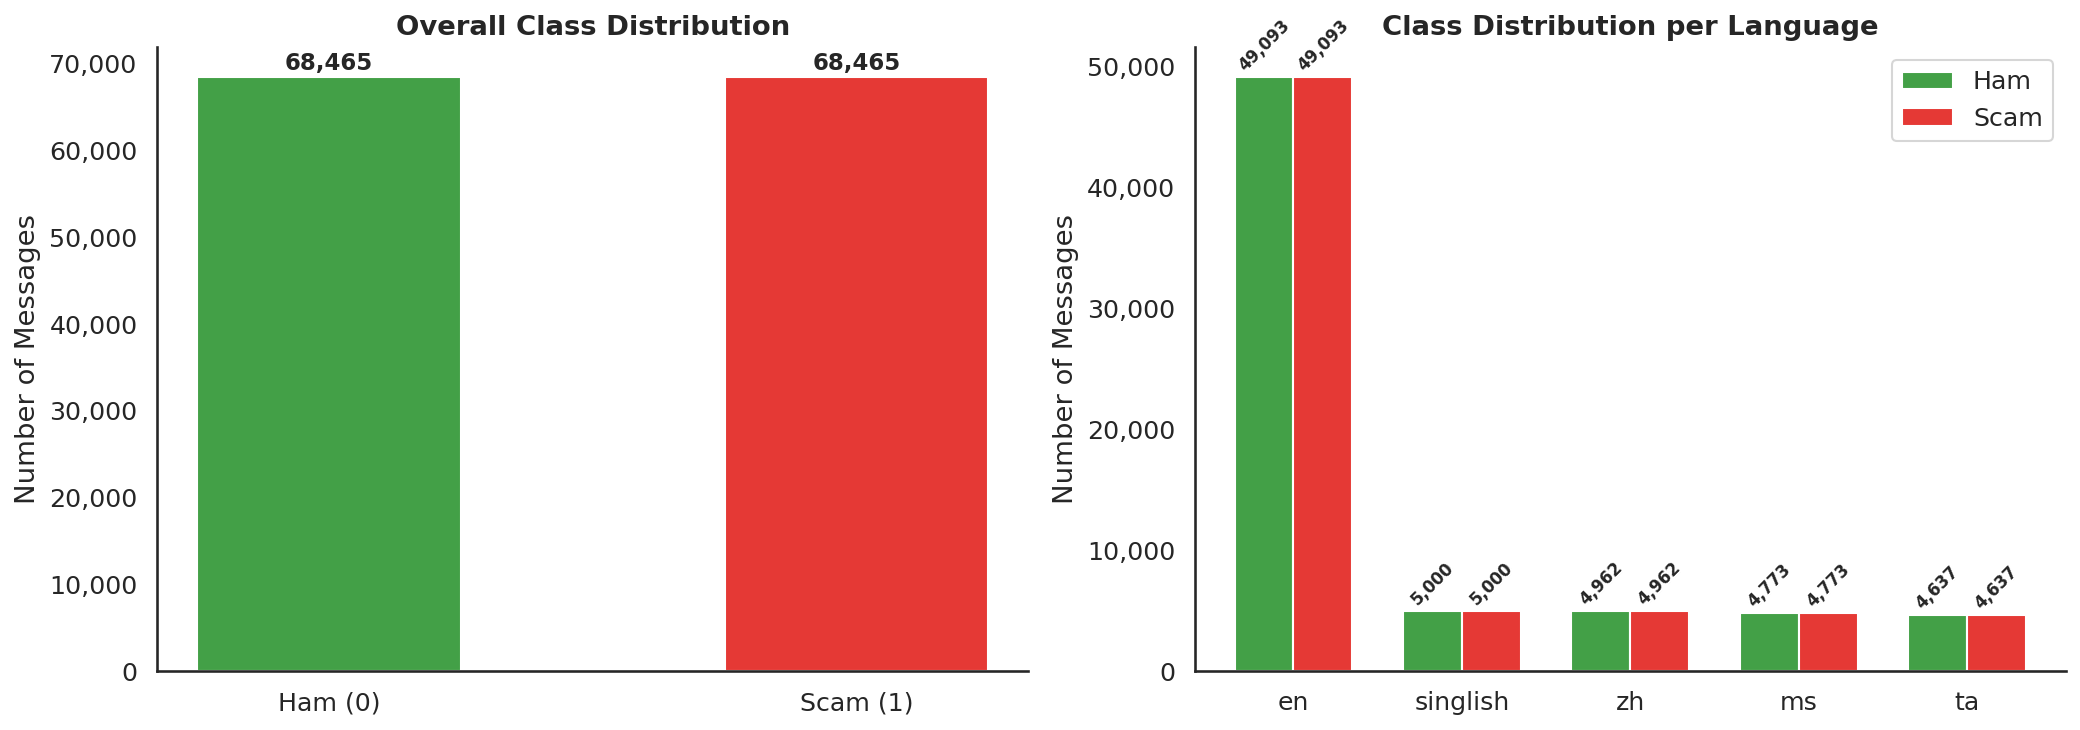

In [ ]:
#plot 01 · overall & per-language class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # two panels side by side: overall, then per-language

# overall
ax = axes[0]
counts = df["label"].value_counts().sort_index()                                 # ham (0) then scam (1) counts
bars = ax.bar(["Ham (0)", "Scam (1)"], counts.values,
              color=[LABEL_COLORS[0], LABEL_COLORS[1]], width=0.5, edgecolor="white")
for bar, val in zip(bars, counts.values):                                        # label each bar with its exact count
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Overall Class Distribution", fontweight="bold")
ax.set_ylabel("Number of Messages")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))  # format y-axis ticks with thousands separators

# per language
ax = axes[1]
lang_label = df.groupby(["language", "label"]).size().unstack(fill_value=0).reindex(columns=[0, 1])  # ham/scam counts per language
lang_order = lang_label.sum(axis=1).sort_values(ascending=False).index                               # sort languages by total message count
lang_label = lang_label.loc[lang_order]
x = range(len(lang_label))
w = 0.35                                                                                             # bar width
ax.bar([i - w/2 for i in x], lang_label[0], width=w, label="Ham",  color=LABEL_COLORS[0], edgecolor="white")
ax.bar([i + w/2 for i in x], lang_label[1], width=w, label="Scam", color=LABEL_COLORS[1], edgecolor="white")

# bold + rotated labels on right panel
for i, (h_val, s_val) in enumerate(zip(lang_label[0], lang_label[1])):  # annotate each bar with its exact count
    ax.text(i - w/2, h_val + 200, f"{h_val:,}",
            ha="center", va="bottom", fontsize=8, fontweight="bold", rotation=45)
    ax.text(i + w/2, s_val + 200, f"{s_val:,}",
            ha="center", va="bottom", fontsize=8, fontweight="bold", rotation=45)

ax.set_xticks(list(x))
ax.set_xticklabels(lang_label.index)
ax.set_title("Class Distribution per Language", fontweight="bold")
ax.set_ylabel("Number of Messages")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
save(fig, "01_class_distribution")  # save the figure to reports/figures/
plt.show()


### 3.2 Global vs per-language label balance after undersampling

✓ 02_label_balance_global_vs_perlang.png


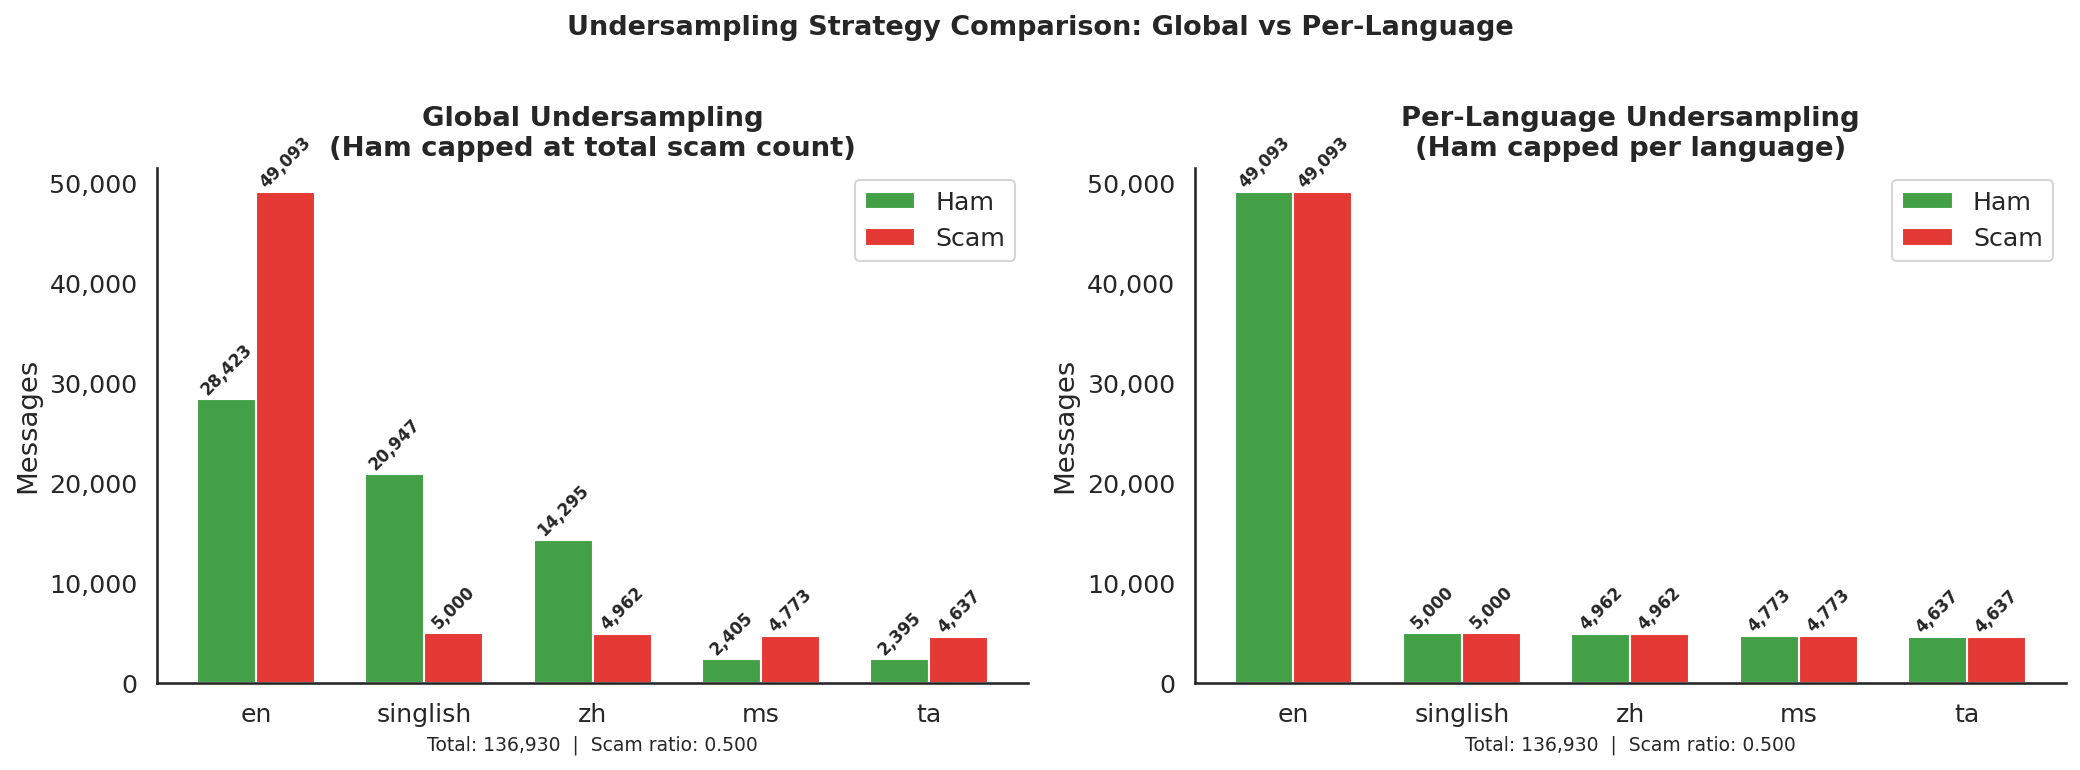

In [ ]:
# plot 02 · global vs per-language label balance after undersampling (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Per-language breakdown using GLOBAL undersampling (df_global)
lang_bal_global = df_global.groupby(["language", "label"]).size().unstack(fill_value=0).reindex(columns=[0, 1])
lang_order = lang_bal_global.sum(axis=1).sort_values(ascending=False).index  # sort languages by total message count
lang_bal_global = lang_bal_global.loc[lang_order]
x = np.arange(len(lang_bal_global))
w = 0.35                                                                     # bar width
ax = axes[0]
ax.bar(x - w/2, lang_bal_global[0], width=w, label="Ham",  color=LABEL_COLORS[0], edgecolor="white")
ax.bar(x + w/2, lang_bal_global[1], width=w, label="Scam", color=LABEL_COLORS[1], edgecolor="white")

for i, (h, s) in enumerate(zip(lang_bal_global[0], lang_bal_global[1])):  # annotate each bar with its exact count
    ax.text(i - w/2, h + 50, f"{h:,}",
            ha="center", va="bottom", fontsize=8, fontweight="bold", rotation=45)
    ax.text(i + w/2, s + 50, f"{s:,}",
            ha="center", va="bottom", fontsize=8, fontweight="bold", rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(lang_bal_global.index)
ax.set_ylabel("Messages")
ax.set_title("Global Undersampling\n(Ham capped at total scam count)", fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
total_g = df_global["label"].value_counts()
ax.set_xlabel(f"Total: {total_g.sum():,}  |  Scam ratio: {total_g[1]/total_g.sum():.3f}", fontsize=9)  # show overall totals under the panel

# RIGHT: Per-language breakdown using PER-LANGUAGE undersampling (df_balanced)
lang_bal = df_balanced.groupby(["language", "label"]).size().unstack(fill_value=0).reindex(columns=[0, 1])
lang_bal = lang_bal.loc[lang_order]  # reuse the same language order as the left panel
x = np.arange(len(lang_bal))
ax = axes[1]
ax.bar(x - w/2, lang_bal[0], width=w, label="Ham",  color=LABEL_COLORS[0], edgecolor="white")
ax.bar(x + w/2, lang_bal[1], width=w, label="Scam", color=LABEL_COLORS[1], edgecolor="white")

for i, (h, s) in enumerate(zip(lang_bal[0], lang_bal[1])):  # annotate each bar with its exact count
    ax.text(i - w/2, h + 50, f"{h:,}",
            ha="center", va="bottom", fontsize=8, fontweight="bold", rotation=45)
    ax.text(i + w/2, s + 50, f"{s:,}",
            ha="center", va="bottom", fontsize=8, fontweight="bold", rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(lang_bal.index)
ax.set_ylabel("Messages")
ax.set_title("Per-Language Undersampling\n(Ham capped per language)", fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
total_b = df_balanced["label"].value_counts()
ax.set_xlabel(f"Total: {total_b.sum():,}  |  Scam ratio: {total_b[1]/total_b.sum():.3f}", fontsize=9)

plt.suptitle("Undersampling Strategy Comparison: Global vs Per-Language", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
save(fig, "02_label_balance_global_vs_perlang")  # save the figure to reports/figures/
plt.show()


### 3.3 Message length analysis


✓ 03_message_length.png


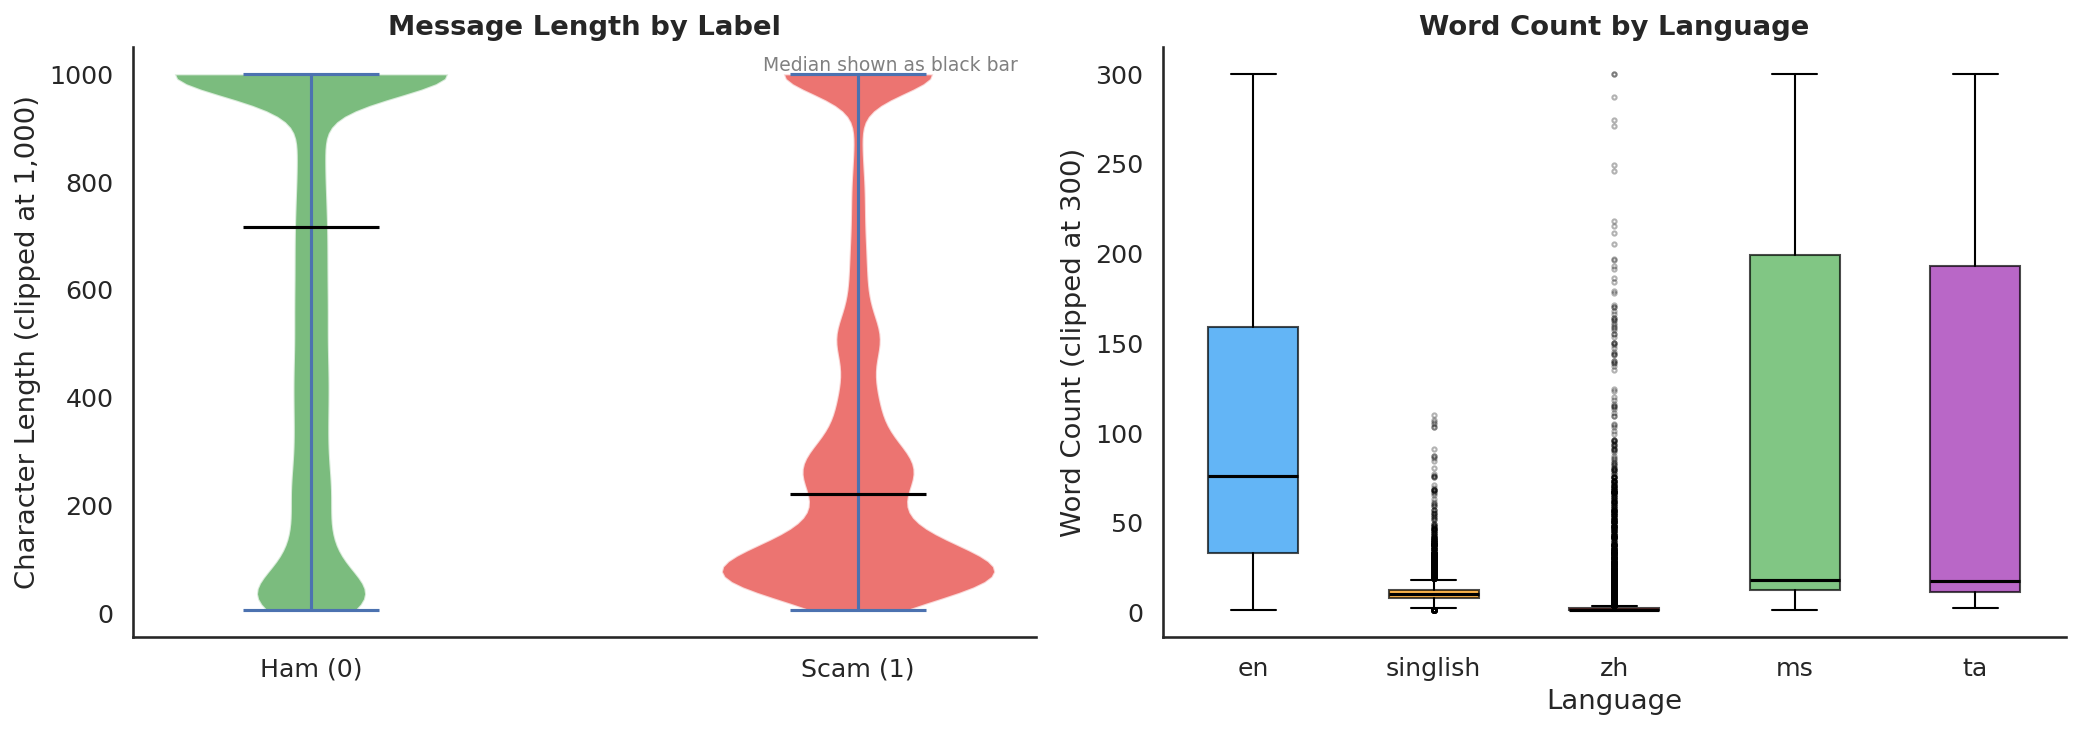


Message length stats:
      char_len                                                  word_count  \
         count   mean    std  min    25%    50%     75%     max      count   
label                                                                        
0      68465.0  875.6  716.3  5.0  217.0  715.0  1507.0  2000.0    68465.0   
1      68465.0  485.8  619.7  6.0   86.0  221.0   527.0  2000.0    68465.0   

                                                   
        mean   std  min   25%   50%    75%    max  
label                                              
0      116.3  95.2  1.0  30.0  95.0  196.0  629.0  
1       62.8  77.5  1.0  12.0  30.0   78.0  689.0  


In [ ]:
# plot 03 · message length analysis (violin + box plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left panel: violin — char length by label
ax = axes[0]
data_by_label = [df.loc[df["label"] == 0, "char_len"].clip(upper=1000),  # clip extreme lengths so the plot isn't squashed by outliers
                 df.loc[df["label"] == 1, "char_len"].clip(upper=1000)]
parts = ax.violinplot(data_by_label, positions=[0, 1], showmedians=True, showextrema=True)
for i, pc in enumerate(parts["bodies"]):                                 # colour each violin to match ham/scam colours
    pc.set_facecolor(list(LABEL_COLORS.values())[i])
    pc.set_alpha(0.7)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(1.5)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Ham (0)", "Scam (1)"])
ax.set_ylabel("Character Length (clipped at 1,000)")
ax.set_title("Message Length by Label", fontweight="bold")
ax.annotate("Median shown as black bar", xy=(0.98, 0.96), xycoords="axes fraction",
            ha="right", fontsize=9, color="gray")

# right panel: box plot — word count by language
ax = axes[1]
lang_order = df["language"].value_counts().index.tolist()                                          # order languages by message count
data_by_lang = [df[df["language"] == l]["word_count"].clip(upper=300).values for l in lang_order]  # clip extreme word counts for readability
bp = ax.boxplot(data_by_lang, labels=lang_order, patch_artist=True,
                medianprops=dict(color="black", linewidth=1.5),
                flierprops=dict(marker="o", markersize=2, alpha=0.3))                              # small, faint markers for outliers

for patch, lang in zip(bp["boxes"], lang_order):  # colour each box to match its language
    patch.set_facecolor(PALETTE.get(lang, "#607D8B"))
    patch.set_alpha(0.7)

ax.set_xlabel("Language")
ax.set_ylabel("Word Count (clipped at 300)")
ax.set_title("Word Count by Language", fontweight="bold")

plt.tight_layout()
save(fig, "03_message_length")  # save the figure to reports/figures/
plt.show()

print("\nMessage length stats:")
print(df.groupby("label")[["char_len", "word_count"]].describe().round(1))  # summary stats (mean, std, quartiles, etc.) per label


### 3.4 Token length distribution

✓ 04_token_length_distribution.png


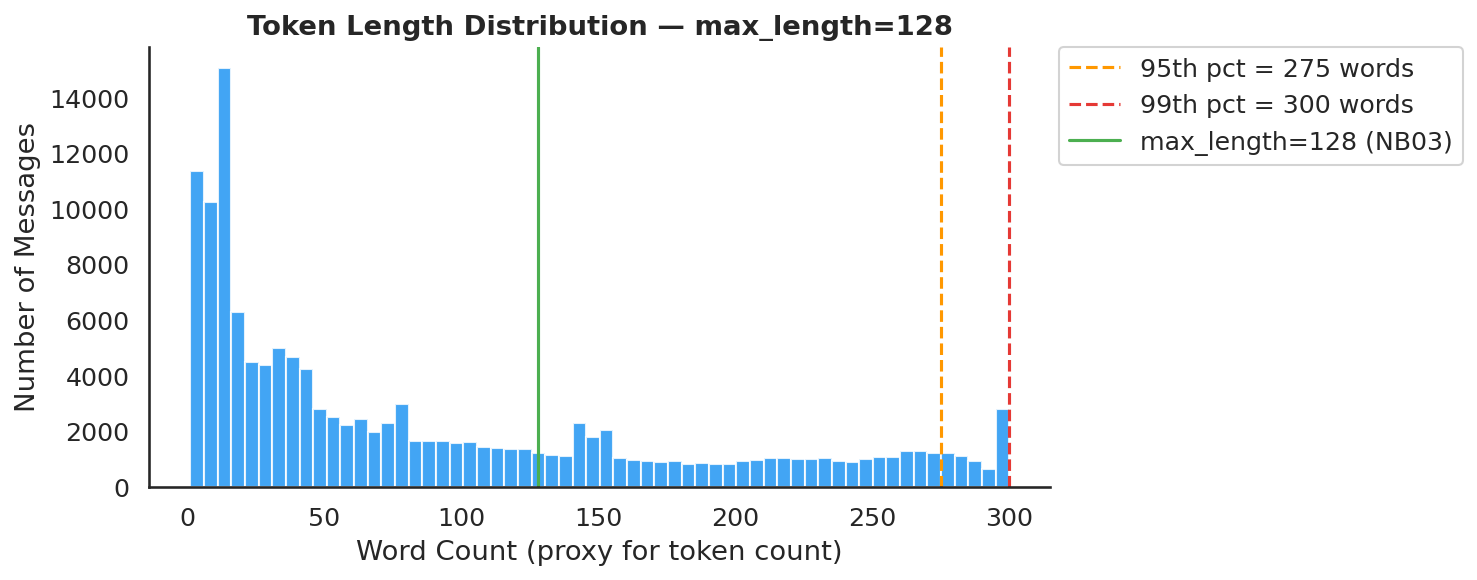

95th percentile word count: 275
99th percentile word count: 300


In [ ]:
# plot 04 · token length distribution (word-proxy)
fig, ax = plt.subplots(figsize=(10, 4))
word_counts = df["text"].astype(str).str.split().str.len().clip(upper=300)  # word count per message, used as a proxy for token count

ax.hist(word_counts, bins=60, color="#2196F3", edgecolor="white", alpha=0.85)
p95 = word_counts.quantile(0.95)  # 95th percentile word count
p99 = word_counts.quantile(0.99)  # 99th percentile word count

ax.axvline(p95, color="#FF9800", linestyle="--", linewidth=1.5, label=f"95th pct = {p95:.0f} words")
ax.axvline(p99, color="#E53935", linestyle="--", linewidth=1.5, label=f"99th pct = {p99:.0f} words")
ax.axvline(128, color="#4CAF50", linestyle="-",  linewidth=1.5, label="max_length=128 (NB03)")  # reference line: the tokeniser truncation length used in NB03

ax.set_xlabel("Word Count (proxy for token count)")
ax.set_ylabel("Number of Messages")
ax.set_title("Token Length Distribution — max_length=128", fontweight="bold")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0, framealpha=0.85)  # place legend outside the plot area

plt.tight_layout()
save(fig, "04_token_length_distribution")  # save the figure to reports/figures/
plt.show()
print(f"95th percentile word count: {p95:.0f}")
print(f"99th percentile word count: {p99:.0f}")


### 3.5 Scam type × language heatmap


✓ 05_scam_type_language_heatmap.png


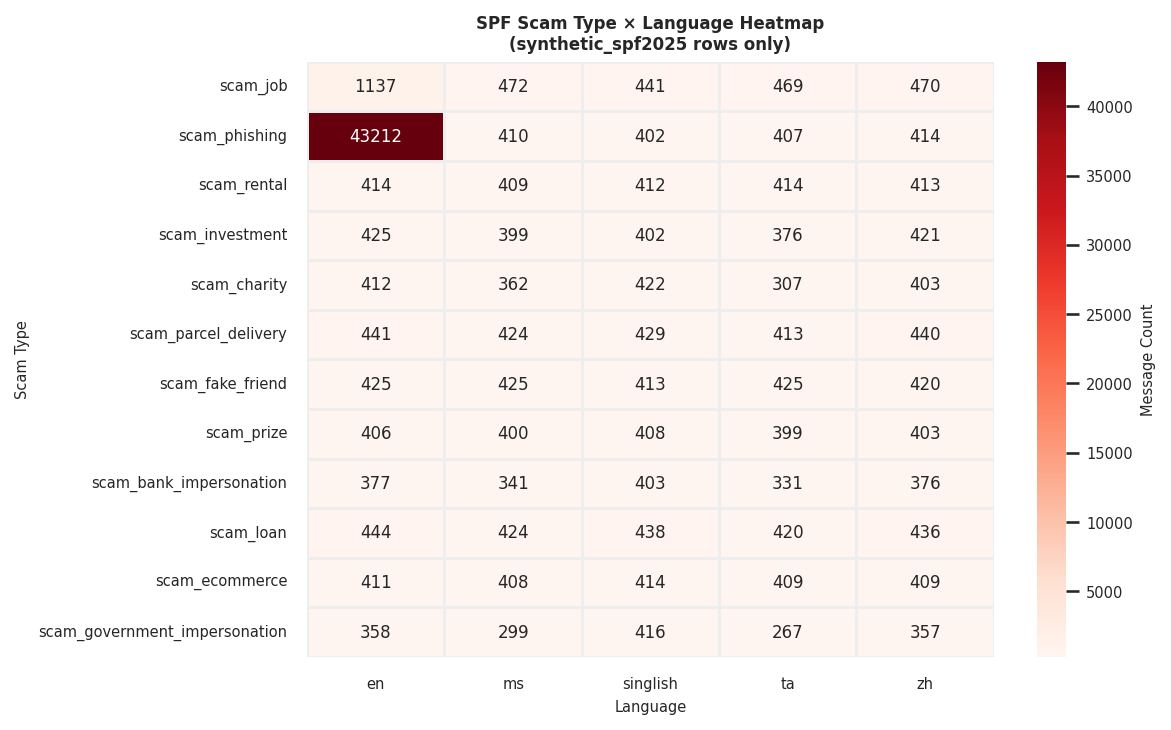

In [ ]:
# plot 05 · SPF scam type × language heatmap
scam_df = df[df["label"] == 1].copy()                                            # only scam rows have a meaningful scam_type
pivot = scam_df.groupby(["scam_type", "language"]).size().unstack(fill_value=0)  # counts of each scam type per language

spf_types = [                                                  # restrict to the 12 SPF scam categories, in a fixed display order
    "scam_job", "scam_phishing", "scam_rental", "scam_investment",
    "scam_charity", "scam_parcel_delivery", "scam_fake_friend",
    "scam_prize", "scam_bank_impersonation", "scam_loan",
    "scam_ecommerce", "scam_government_impersonation"
]
pivot = pivot.loc[[t for t in spf_types if t in pivot.index]]  # keep only rows that exist in the data, in that order

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True, fmt="d", cmap="Reds",  # show integer counts inside each cell
    linewidths=0.5, linecolor="#eee", ax=ax,
    annot_kws={"size": 8},
    cbar_kws={"label": "Message Count"}
)

ax.set_title("SPF Scam Type × Language Heatmap\n(synthetic_spf2025 rows only)",
             fontweight="bold", fontsize=8)
ax.set_xlabel("Language", fontsize=7)
ax.set_ylabel("Scam Type", fontsize=7)
ax.tick_params(axis="x", rotation=0, labelsize=7)
ax.tick_params(axis="y", rotation=0, labelsize=7)
ax.collections[0].colorbar.ax.tick_params(labelsize=7)  # shrink the colour-bar tick labels to match
ax.collections[0].colorbar.set_label("Message Count", size=7)

plt.tight_layout()
save(fig, "05_scam_type_language_heatmap")  # save the figure to reports/figures/
plt.show()


### 3.6 Data quality summary

In [ ]:
print("DATA QUALITY REPORT")

# label conflicts — same text with both labels
conflicts = (df.groupby("text")["label"].nunique().reset_index().query("label > 1"))  # find texts that appear with more than one distinct label
print(f"1. Label conflicts (same text, different labels): {len(conflicts):,}")

# very short messages
short = df[df["char_len"] < 5]  # should be ~0 since these were dropped during cleaning
print(f"2. Very short messages (< 5 chars): {len(short):,}")

# very long messages
long_msgs = df[df["char_len"] > 5000]  # flag unusually long messages for review
print(f"3. Very long messages (> 5,000 chars): {len(long_msgs):,}")

# literal nan strings
nan_str = df[df["text"].str.lower() == "nan"]  # should be ~0 since these were dropped during cleaning
print(f"4. Rows with literal nan text: {len(nan_str):,}")

if len(conflicts) > 0:  # warn if any label conflicts remain
    print("Review label conflicts before training.")


DATA QUALITY REPORT
1. Label conflicts (same text, different labels): 0
2. Very short messages (< 5 chars): 0
3. Very long messages (> 5,000 chars): 0
4. Rows with literal nan text: 0


### 3.7 EDA summary table

In [ ]:
rows = []  # collect one summary row per language

for lang in df["language"].unique():  # compute summary stats for each language
    sub = df[df["language"] == lang]
    rows.append({
        "language":        lang,
        "total_rows":      len(sub),
        "scam_rows":       int((sub["label"] == 1).sum()),
        "ham_rows":        int((sub["label"] == 0).sum()),
        "balance_ratio":   round((sub["label"] == 1).sum() / len(sub), 3),
        "avg_char_len":    round(sub["char_len"].mean(), 1),
        "median_char_len": round(sub["char_len"].median(), 1),
        "avg_word_count":  round(sub["word_count"].mean(), 1),
    })

summary = pd.DataFrame(rows).sort_values("total_rows", ascending=False)  # largest languages first

totals = {  # add one final row with dataset-wide totals
    "language":        "TOTAL",
    "total_rows":      len(df),
    "scam_rows":       int((df["label"] == 1).sum()),
    "ham_rows":        int((df["label"] == 0).sum()),
    "balance_ratio":   round((df["label"] == 1).sum() / len(df), 3),
    "avg_char_len":    round(df["char_len"].mean(), 1),
    "median_char_len": round(df["char_len"].median(), 1),
    "avg_word_count":  round(df["word_count"].mean(), 1),
}
summary = pd.concat([summary, pd.DataFrame([totals])], ignore_index=True)

summary_path = os.path.join(REPORT_DIR, "eda_summary.csv")
summary.to_csv(summary_path, index=False, encoding="utf-8-sig")  # save the summary table as a CSV
print("EDA SUMMARY")
display(summary)
print(f"\nSaved: {summary_path}")

print("\nFigures in reports/figures/:")
for f in sorted(os.listdir(FIGURES_DIR)):  # list every saved EDA plot as a final confirmation
    print(f"  {f}")


EDA SUMMARY


,language,total_rows,scam_rows,ham_rows,balance_ratio,avg_char_len,median_char_len,avg_word_count
0,en,98186,49093,49093,0.5,791.9,531.0,106.3
1,singlish,10000,5000,5000,0.5,56.0,53.0,10.7
2,zh,9924,4962,4962,0.5,130.6,28.0,4.9
3,ms,9546,4773,4773,0.5,673.7,138.0,92.4
4,ta,9274,4637,4637,0.5,773.4,150.0,85.1
5,TOTAL,136930,68465,68465,0.5,680.7,370.0,89.5



Saved: /kaggle/working/reports/eda_summary.csv

Figures in reports/figures/:
  01_class_distribution.png
  02_label_balance_global_vs_perlang.png
  03_message_length.png
  04_token_length_distribution.png
  05_scam_type_language_heatmap.png
